In [1]:
#volume average
def vol_avg(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN'] 
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        prof_sized_vol_avg = prof_sized_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_sized_vol_avg
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        prof_vol_avg = prof_vol_int/omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], 1)[-1]
        return prof_vol_avg

#H factor definitions
def vol_integral(geqdsk, prof, rho_prof = None): #rho_prof is only specified if integrating a quantity outside the geqdsk
    if rho_prof is not None:
        rho_geqdsk = geqdsk['RHOVN']
        prof_sized = np.interp(rho_geqdsk,rho_prof,prof)
        prof_sized_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof_sized)[-1]
        return prof_sized_vol_int
    
    else:
        prof_vol_int = omfit_eqdsk.fluxSurfaces.volume_integral(geqdsk['fluxSurfaces'], prof)[-1]
        return prof_vol_int

def taue_h_mode(x,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58): #M = 2.5 for DT
    h_mode_vars = [x['ip'],x['bcentr'],x['density'],x['ptot_cps'],x['rsurf'],x['kappa'],x['eps']]
    return 0.0562*2.5**(0.19)*np.prod(np.power(h_mode_vars,np.array([a1,a2,a3,a4,a5,a6,a7])))

def taue_l_mode(x,a1=0.85,a2=1.2,a3=0.3,a4=0.5,a5=0.1,a6=0.2,a7=-0.5): #M = 2.5 for DT
    l_mode_vars = [x['ip'],x['rsurf'],x['aminor'],x['kappa'],x['density']/10,x['bcentr'],x['ptot_cps']] #this scaling law uses n20
    return 0.048*2.5**(0.5)*np.prod(np.power(x,np.array([a1,a2,a3,a4,a5,a6,a7])),axis=1)

def get_params_dict(gfile,ffile):
    ip = abs(ffile['ip'][-1])
    bt = abs(ffile['b0'][-1])
    
    rho_tor_norm = ffile['rho'][:]
    e_density_profile = ffile['ne'][-1] #10^19
    density_19_avg = vol_avg(gfile,e_density_profile,rho_tor_norm)
    
    Palpha = (ffile['pfuse'][-1] + ffile['pfusi'][-1]) #multiply by 5 would give fusion power, don't do for this
    Ptot = ffile['prfe'][-1] + ffile['prfi'][-1] + Palpha
    Rmaj = gfile['fluxSurfaces']['geo']['R'][-1]
    kappa = gfile['fluxSurfaces']['geo']['kap'][-1]
    aminor = gfile['fluxSurfaces']['geo']['a'][-1]
    eps = gfile['fluxSurfaces']['geo']['eps'][-1]
    params_dict = {'ip':ip,'bcentr':bt,'density':density_19_avg,'ptot_cps':Ptot,'rsurf':Rmaj,'kappa':kappa,'eps':eps,'aminor':aminor}
    return params_dict

def calc_H98y2(gfile,ffile):
    rho = ffile['rho'][:]
    ne_prof = ffile['ne'][-1,:] #10^19/m^3
    Te_prof = ffile['te'][-1,:] #keV
    ni_prof_tot = ffile['ni'][-1,:] + ffile['nz0'][-1,:] + ffile['nhe'][-1,:]
    Ti_prof = ffile['ti'][-1,:]
    #total_pressure = (ne_prof*Te_prof+ni_prof_tot*Ti_prof)*1602.2  #to convert to Pa (multiplication is for from eV to Joules)
    #use geqdsk pressure for now
    total_pressure = gfile['PRES']
    
    Wthr = vol_integral(gfile,(3/2)*total_pressure)/1e6 #MJ
    #print('Wthr =',Wthr)

    params_dict = get_params_dict(gfile,ffile)
    #print(params_dict)
    tau_H98y2 = taue_h_mode(params_dict,a1=0.93,a2=0.15,a3=0.41,a4=-0.69,a5=1.97,a6=0.78,a7=0.58)
    #print('tau_H98y2 =',tau_H98y2)
    tau_E = Wthr/params_dict['ptot_cps']
    #print('tau_E =',tau_E)
    H98y2 = tau_E/tau_H98y2
    #print('H98y2 =',H98y2)

    return H98y2

In [2]:
from netCDF4 import Dataset
from sys import argv
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

['simulation_564690_0005', 'simulation_564690_0002', 'simulation_564690_0001', 'simulation_564690_0003', 'simulation_564690_0004', 'simulation_564690_0000']
/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+PELLET+TGLF/SCAN_xmid_ptclsconstant/SCAN/simulation_564690_0005/work/fastran_tr_fastran_57/fastran.nc
/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+PELLET+TGLF/SCAN_xmid_ptclsconstant/SCAN/simulation_564690_0002/work/fastran_tr_fastran_30/fastran.nc
/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+PELLET+TGLF/SCAN_xmid_ptclsconstant/SCAN/simulation_564690_0001/work/fastran_tr_fastran_21/fastran.nc
/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+PELLET+TGLF/SCAN_xmid_ptclsconstant/SCAN/simulation_564690_0003/work/fastran_tr_fastran_39/fastran.nc
/pscratch/sd/h/hswils/github_repos/MANTA_DBSCANS/IC+RAD+PELLET+TGLF/SCAN_xmid_ptclsconstant/SCAN/simulation_564690_0000/work/fastran_tr_fastran_12/fastran.nc


/tmp/ipykernel_393230/1000945274.py:142: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('cool')


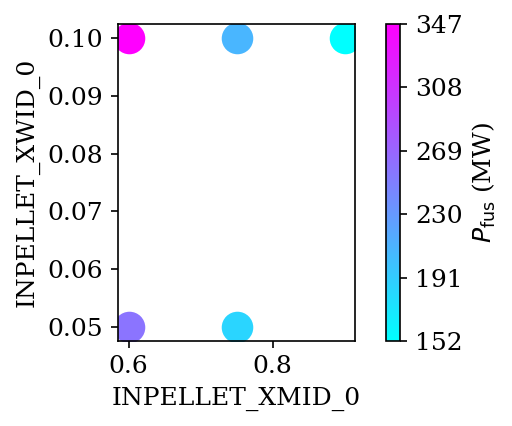

In [4]:
with plt.rc_context({
    #"text.usetex": True,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "figure.autolayout":True,
    #"legend.frameon" : False,
    "lines.linewidth" : 3.0,
    "lines.markeredgewidth" : 0.0,
    "lines.markersize" : 6.0

}):
    # DEFINE FIGURE ===========================
    fig = plt.figure('fig_offset', figsize=(3.58,3),dpi = 150)
    gs = mpl.gridspec.GridSpec(1,2, figure=fig, width_ratios=[1,0.06])
    axs = {}
    axs[1] = fig.add_subplot(gs[0,0])
    #axs[2] = fig.add_subplot(gs[1,0])
    axs[3] = fig.add_subplot(gs[0,1])
    #axs[4] = fig.add_subplot(gs[1,1])
    
    ax1 = axs[1]
    #ax2 = axs[2]
    ax1cb = axs[3]


    # Define arrays ===========================
    irf_array = []
    prf_array = []
    pfus_array = []
    jrf_array_array = [] #array_arrays are for profiles that I want colored with a colorbar
    psol_array = []
    te_array_array = []
    ne_array_array = []
    pe_array_array = []
    betan_array = []
    pfus_array_array = []
    p_array_array = []
    param_0_array = []
    param_1_array = []

    # Find the fastran.nc file ================
    cwd = os.getcwd()
    SCAN_dir = cwd+'/SCAN'
    sims = [f for f in os.listdir(SCAN_dir) if f.startswith('simulation_') and not f.endswith('.conf') and not f.endswith('log')]
    print(sims)
    
    for sim in sims[:4]+[sims[-1]]:
        work_dir = SCAN_dir+'/'+sim+'/work'
        fastran_dir = [f for f in os.listdir(work_dir) if f.startswith('fastran_tr_')]
        ffile = work_dir+'/'+fastran_dir[0]+'/fastran.nc'
        rootgrp = Dataset(ffile)

        print(ffile)

        # GET PARAMETERS FROM SCAN FILE
        param_file = SCAN_dir+'/'+sim+'/'+'parameters.conf'
        params_table = np.genfromtxt(param_file,dtype=None,usecols=[1,2])
    
        param_0_name,param_0_val = params_table[-1]
        param_1_name,param_1_val = params_table[-2]

        param_0_array.append(param_0_val)
        param_1_array.append(param_1_val)

        #Define variables from netcdf file -------------------------------
        rho = rootgrp['rho'][:]

        # densities
        ne = rootgrp['ne'][-1,:]
        nebar = rootgrp['nebar'][-1]
        ni = rootgrp['ni'][-1,:]
        nz = rootgrp['nz0'][-1,:]
        nhe = rootgrp['nhe'][-2,:]
        ne_array_array.append(ne)

        # temperatures
        te = rootgrp['te'][-1,:]
        teavg = rootgrp['tea'][-1]
        ti = rootgrp['ti'][-1,:]
        tiavg = rootgrp['tia'][-1]

        
        te_array_array.append(te)
        pe_array_array.append(ne*te)
    
        ipol = rootgrp['ipol'][-1,:]
        ip = rootgrp['ip'][-1]
    
        prfe = rootgrp['pe_rf'][-1,:]
        prfe_int = rootgrp['prfe'][-1]
        prfi = rootgrp['pi_rf'][-1,:]
        prfi_int = rootgrp['prfi'][-1]
    
        pfuse = rootgrp['pe_fus'][-1,:]
        pfuse_int = rootgrp['pfuse'][-1]
        pfusi = rootgrp['pi_fus'][-1,:]
        pfusi_int = rootgrp['pfusi'][-1]

        prad_int = rootgrp['prad'][-1]
    
        q = rootgrp['q'][-1,:]
    
        jbs = rootgrp['j_bs'][-1,:]
        ibs = rootgrp['ibs'][-1]
        joh = rootgrp['j_oh'][-1,:]
        jrf = rootgrp['j_rf'][-1,:]
        irf = rootgrp['irf'][-1]
        jtot = rootgrp['j_tot'][-1,:]
    
        fluxe = rootgrp['fluxe'][-1,:]
        fluxe_exp = rootgrp['fluxe_exp'][-1,:]
        fluxi = rootgrp['fluxi'][-1,:]
        fluxi_exp = rootgrp['fluxi_exp'][-1,:]

        betan = rootgrp['betan'][-1]

        betan_array.append(betan)
        irf_array.append(irf)
        prf_array.append(prfe_int+prfi_int)
        pfus_array.append(5*(pfuse_int+pfusi_int))
        psol_array.append((pfuse_int+pfusi_int)+prfe_int+prfi_int-prad_int) # is this right?

        pfus_array_array.append((5*(pfuse+pfusi)))
        p_array_array.append(ne*te + (ni+nz+nhe)*ti)
        jrf_array_array.append(jrf)

        var_dic = {'ne':ne,'ni':ni,'te':te,'ti':ti,'ipol':ipol,'joh':joh,'jbs':jbs,'jrf':jrf,'jtot':jtot,'pfus':5*(pfuse+pfusi),'paux':prfe+prfi,'q':q}
        lw = 2
        c1 = 'green'
        c2 = 'lime'
        c3 = 'magenta'
        c4 = 'darkviolet'
        c5 = 'dodgerblue'
        c6 = 'cyan'

    cvar = pfus_array
    yvar = param_0_array
    xvar = param_1_array

    # set colors for colorbar
    cmap = cm.get_cmap('cool')
    cmin = min(cvar)
    cmax = max(cvar)
    cs = (cvar-cmin)/(cmax-cmin)
    c = cmap(cs)
    order = np.argsort(cs)
    
    # make colorbar
    Ncb = 6
    ticks = np.linspace(0,1,Ncb); ticklabels = np.linspace(cmin,cmax,Ncb)
    #norm = mpl.colors.BoundaryNorm([int(cvar[i]) for i in order], cmap.N)
    cb1 = mpl.colorbar.ColorbarBase(ax1cb, orientation='vertical',cmap=cmap,ticks = ticks)#, norm=norm)
    ticklabels = ['{:1.0f}'.format(x) for x in ticklabels]
    ticklabels[0] = f'{ticklabels[0]}'
    ticklabels[-1] = f'{ticklabels[-1]}'
    cb1.set_ticklabels(ticklabels)

    ax1cb.set_ylabel('${P_\\mathrm{fus}}$ (MW)')


    
    for i in order:
        ax1.scatter(xvar[i],yvar[i],color=c[i],s=200)
        
        #ax1.text(0.7,1-0.1*i,'$P_\mathrm{aux} = %.0f$ MW' % (prf_array[i]), color = c[i],transform=ax1.transAxes)
        #ax1cb.scatter(prf_array[i],irf_array[i],color=c[i])


#     norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

# fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
#              cax=ax, orientation='horizontal',
#              label="Discrete intervals with extend='both' keyword")
    
    # ax1cb.set_xlabel('$P_\mathrm{aux}$ (MW)',fontsize = 10)
    # ax1cb.set_ylabel('$I_\mathrm{rf}$ (MW)',fontsize = 10)
    # ax1cb.set_ylim(0.1,0.3)
    # ax1cb.tick_params(axis='both', which='major', labelsize=8)
    # ax1cb.tick_params(axis='both', which='minor', labelsize=8)
    
    ax1.set_xlabel(param_1_name)
    ax1.set_ylabel(param_0_name)

    ## UNCOMMENT FOR Pfus, Qplasma plot
    # ax2.scatter(prf_array,pfus_array,color='k')

    # Q = np.array(pfus_array)/np.array(prf_array)
    # ax2.set_xlabel('$P_\\mathrm{aux}$ (MW)')
    # ax2.set_ylabel('$P_\\mathrm{fus}$ (MW)')
    # ax2.set_ylim(300,450)
    # ax3 = ax2.twinx()
    # ax3.scatter(prf_array,Q,marker='*',color = 'limegreen')
    # ax3.set_ylabel('$Q_\\mathrm{plasma}$')
    # ax3.yaxis.label.set_color('limegreen')
    plt.show()

    


In [6]:
print(rootgrp.variables)


{'time': <class 'netCDF4._netCDF4.Variable'>
float64 time(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'rho': <class 'netCDF4._netCDF4.Variable'>
float64 rho(rho)
unlimited dimensions: 
current shape = (101,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'r0': <class 'netCDF4._netCDF4.Variable'>
float64 r0(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'b0': <class 'netCDF4._netCDF4.Variable'>
float64 b0(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'a0': <class 'netCDF4._netCDF4.Variable'>
float64 a0(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.969209968386869e+36 used, 'amain': <class 'netCDF4._netCDF4.Variable'>
float64 amain(time)
unlimited dimensions: time
current shape = (3,)
filling on, default _FillValue of 9.96